Membership matrix (U): 
 [[9.99999670e-01 1.00000000e+00 9.99999670e-01 1.00000000e+00
  1.00000000e+00 1.00000000e+00 9.99999979e-01 7.73513096e-01
  4.74768096e-07 1.69785928e-10 1.63291943e-20 1.69785928e-10
  3.20690214e-07 7.04461009e-14 3.20690214e-07]
 [3.29826988e-07 9.67360499e-13 3.29826988e-07 6.27471896e-11
  3.72026182e-29 6.27471896e-11 2.06632095e-08 2.26486904e-01
  9.99999525e-01 1.00000000e+00 1.00000000e+00 1.00000000e+00
  9.99999679e-01 1.00000000e+00 9.99999679e-01]]
Cluster centers: 
 [[0.92918566 2.        ]
 [5.23604325 2.        ]]
Labels: 
 [0 0 0 0 0 0 0 0 1 1 1 1 1 1 1]


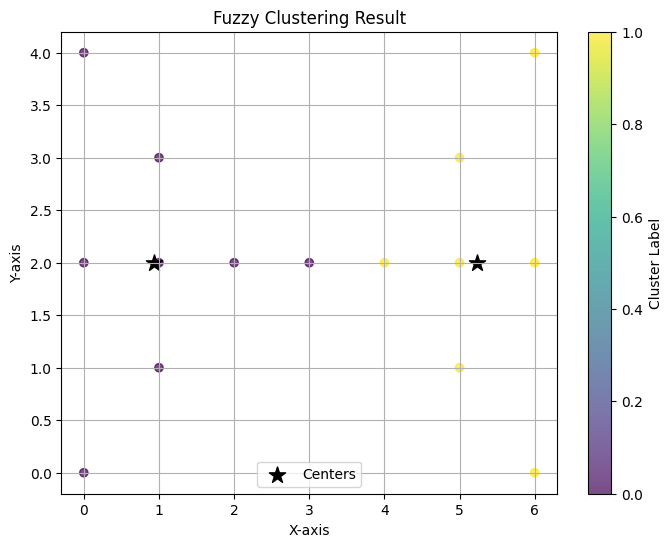

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Input data
X = np.array([0, 0, 0, 1, 1, 1, 2, 3, 4, 5, 5, 5, 6, 6, 6])
Y = np.array([4, 2, 0, 3, 2, 1, 2, 2, 2, 3, 2, 1, 4, 2, 0])
data = np.array([(i, j) for i, j in zip(X, Y)])

def fuzzy_clustering(data, num_clusters, fuzziness=1.25, max_iter=100, tol=0.001):
    n_samples = data.shape[0]
    n_features = data.shape[1]

    U = np.random.rand(num_clusters, n_samples)
    U = U / np.sum(U, axis=0)
    centers = np.random.random((num_clusters, n_features)) * (data.max() - data.min()) + data.min()

    for iteration in range(max_iter):
        U_old = U.copy()

        # Compute cluster centers
        for c in range(num_clusters):
            u_m = U[c] ** fuzziness
            numerator = np.sum(u_m[:, np.newaxis] * data, axis=0)
            denominator = np.sum(u_m)
            centers[c] = numerator / denominator

        # Compute distances and update U
        distances = np.zeros((num_clusters, n_samples))
        for c in range(num_clusters):
            diff = data - centers[c]
            distances[c] = np.sum(diff ** 2, axis=1)

        U = np.zeros((num_clusters, n_samples))
        for i in range(n_samples):
            if np.any(distances[:, i] == 0):
                for c in range(num_clusters):
                    if distances[c, i] == 0:
                        U[c, i] = 1
                    else:
                        U[c, i] = 0
            else:
                for c in range(num_clusters):
                    U[c, i] = 1 / np.sum([(distances[c, i] / distances[k, i]) ** (2 / (fuzziness - 1))
                                          for k in range(num_clusters)])

        # Termination condition
        if np.max(np.abs(U - U_old)) <= tol:
            break

    labels = np.argmax(U, axis=0)
    return U, centers, labels

# Run the algorithm
num_clusters = 2
fuzziness = 1.25 # به گفته استاد که معمولااین عدد استفاده میشه
U, centers, labels = fuzzy_clustering(data, num_clusters, fuzziness)

# Print results
print("Membership matrix (U):", '\n', U)
print("Cluster centers:", '\n', centers)
print("Labels:", '\n', labels)

# Plotting function
def visualize_clusters(data, labels, centers):
    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(data[:, 0], data[:, 1], c=labels, cmap='viridis', alpha=0.7)
    plt.scatter(centers[:, 0], centers[:, 1], c='black', marker='*', s=150, label='Centers')
    plt.title('Fuzzy Clustering Result')
    plt.xlabel('X-axis')
    plt.ylabel('Y-axis')
    plt.colorbar(scatter, label='Cluster Label')
    plt.legend()
    plt.grid(True)
    plt.show()

# Visualize results
visualize_clusters(data, labels, centers)